# Métodos avanzados: medidas de similaridad y distancia

## Introducción

En ciencia de datos, una tarea recurrente consiste en cuantificar qué tan parecidos o distintos son dos objetos entre sí. Dependiendo de la naturaleza de esos objetos —cadenas de texto, vectores numéricos, documentos— se utilizan métricas distintas.

En esta sección presentamos las principales medidas de similaridad y distancia que aparecen en el análisis de datos, organizadas en tres grandes bloques: medidas para cadenas de texto, distancias para datos numéricos, y similaridad de coseno para representaciones vectoriales de documentos.

## Medidas de similaridad entre cadenas de texto
Cuando los datos contienen nombres de personas, municipios, productos u otras cadenas de caracteres ingresadas manualmente, es habitual encontrar variantes ortográficas, abreviaturas, errores tipográficos u omisiones. Para poder comparar y vincular esos registros de manera flexible —en lugar de exigir coincidencias exactas— se utilizan métricas de similaridad entre cadenas.

### Similaridad de Jaro

La **similaridad de Jaro** entre dos cadenas $s_1$ y $s_2$ se define como:

$$sim_J = \frac{1}{3}\big(\frac{m}{|s_1|} + \frac{m}{|s_2|} + \frac{m-t}{m})$$

donde:

- $∣s_i∣$ es la longitud de la cadena $s_i$.

- $m$ es el número de caracteres coincidentes entre ambas cadenas.

- $t$ es la mitad del número de transposiciones entre los caracteres que coinciden.

**¿Cuándo se consideran coincidentes dos caracteres?**

Dos caracteres se consideran coincidentes si son iguales y la distancia entre sus posiciones en las respectivas cadenas no supera el umbral:

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1$$

Este umbral permite capturar coincidencias aunque los caracteres no estén exactamente en la misma posición. 

La similaridad de Jaro toma valores en el intervalo [0, 1]: el valor 1 indica cadenas idénticas y el valor 0 indica que no hay ningún carácter coincidente dentro de la ventana de caracteres definida por la expresión que se presentó anteriormente.

### Similaridad de Jaro-Winkler
Winkler propuso una modificación a la fórmula de Jaro que incrementa la similaridad cuando las cadenas comparadas comparten un prefijo común. La intuición detrás de esta corrección es que en muchos dominios prácticos —nombres propios, palabras en un idioma— los errores tipográficos son más frecuentes hacia el final de la cadena que al comienzo.

$$sim_{JW} = sim_J + lp(1 − sim_J)$$

donde:

- $sim_J$ es la similaridad de Jaro entre $s_1$ y $s_2$.

- $l$ es la longitud del prefijo común al inicio de ambas cadenas, hasta un máximo de 4 caracteres.

- $p$ es un factor de escalado que controla cuánto se bonifica la coincidencia en el prefijo. No debe superar 0.25. El valor estándar es $p = 0.1$.

Se puede verificar fácilmente que cuando las cadenas no comparten prefijo ($l = 0$), la fórmula de Jaro-Winkler se reduce exactamente a la de Jaro.

#### Cálculo paso a paso de la similaridad de Jaro

Para entender cómo funciona el algoritmo, vamos a calcular la similaridad de Jaro entre las siguientes dos cadenas:

- $s_1$: `ARGENTINA`

- $s_2$: `ARGENTEAN`

Las longitudes de estas cadenas son $|s_1| = |s_2| = 9$. 

**Paso 1: determinar el umbral de coincidencia**

Dos caracteres se consideran coincidentes si son iguales y la distancia entre sus posiciones no supera:

$$\big[\frac{max(|s_1|, |s_2|)}{2}\big] - 1 = 4 - 1 = 3$$

Es decir, un carácter en la posición $k$ de $s_1$ puede coincidir con un carácter en $s_2$ siempre que este se encuentre en alguna posición entre $k-3$ y $k+3$.

**Paso 2: identificar los caracteres coincidentes y calcular $m$**

Alineamos las cadenas posición a posición para facilitar la visualización:

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Pos.</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">9</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>1</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">G</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">I</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">s<sub>2</sub></td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">G</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
    </tr>
  </tbody>
</table>

Recorremos $s_1$ caracter por caracter y buscamos, dentro del umbral de 3 posiciones, si ese carácter aparece en $s_2$ (sin reutilizar caracteres ya emparejados):

- A (pos. 1): coincide con la A en pos. 1 de $s_2$ (distancia 0).

- R (pos. 2): coincide con la R en pos. 2 de $s_2$ (distancia 0). 

- G (pos. 3): coincide con la G en pos. 3 de $s_2$ (distancia 0).

- E (pos. 4): coincide con la E en pos. 4 de $s_2$ (distancia 0). 

- N (pos. 5): coincide con la N en pos. 5 de $s_2$ (distancia 0).

- T (pos. 6): coincide con la T en pos. 6 de $s_2$ (distancia 0).

- I (pos. 7): no hay ninguna I en $s_2$ dentro del rango [4, 9].

- N (pos. 8): coincide con la N en pos. 9 de $s_2$ (distancia 1).

- A (pos. 9): coincide con la A en pos. 8 de $s_2$ (distancia 1).

Por lo tanto, $m = 7$.

**Paso 3: identificar las transposiciones y calcular $t$**

Para calcular las transposiciones, construimos una nueva tabla listando únicamente los caracteres coincidentes. Tanto para $s_1$ como para $s_2$ los tomamos en el orden en que aparecen en las cadenas originales:

<table style="border-collapse: collapse; text-align: center; font-family: monospace; font-size: 1em; margin-bottom: 20px;">
  <thead>
    <tr style="background-color: #e8e8e8;">
      <th style="border: 1px solid #ccc; padding: 8px 14px;">Par</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">1</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">2</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">3</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">4</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">5</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">6</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">7</th>
      <th style="border: 1px solid #ccc; padding: 8px 14px;">8</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_1$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">G</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
    </tr>
    <tr>
      <td style="border: 1px solid #ccc; padding: 8px 14px; font-weight: bold;">Coincidentes en $s_2$</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">R</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">G</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">E</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">N</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px;">T</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">A</td>
      <td style="border: 1px solid #ccc; padding: 8px 14px; background-color: #ffd6d6;">N</td>
    </tr>
  </tbody>
</table>

Los primeros seis pares coinciden posición a posición. En los dos últimos, en cambio, el carácter de $s_1$ y el de $s_2$ son distintos: donde $s_1$ tiene N, $s_2$ tiene A, y viceversa. Estos son los 2 caracteres transpuestos (resaltados en rojo). Según la definición de Jaro, $t$ es la mitad de ese conteo:  

$$t = \frac{2}{2} = 1$$

**Paso 4: calcular la similaridad de Jaro**

Con $m = 7$, $|s_1| = |s_2| = 9$ y $t = 1$:

$$sim_J = \frac{1}{3}\big(\frac{7}{9} + \frac{7}{9} + \frac{7 - 1}{7}\big) \approx 0.8843$$

#### Cálculo de la similaridad de Jaro-Winkler
Ambas cadenas comparten el prefijo `ARGENT` (6 caracteres), pero Jaro-Winkler considera hasta un máximo de 4, por lo que $l = 4$. Con el valor estándar $p = 0.1$:

$$sim_{JW} = 0.8843 + 4~0.1(1 − 0.8843) = 0.9306$$

La coincidencia del prefijo `ARGE` tiene el efecto de aumentar la similaridad de 0.88 a 0.93.

#### Implementación en Python: librería rapidfuzz
`RapidFuzz` es una biblioteca de código abierto para *fuzzy string matching* y cálculo de métricas de similaridad entre cadenas. Está implementada principalmente en C++ con bindings para Python, lo que la hace muy eficiente incluso para colecciones grandes de cadenas.

Para calcular las similaridades de Jaro y Jaro-Winkler importamos las clases correspondientes del módulo `rapidfuzz.distance`:

In [1]:
from rapidfuzz.distance import Jaro, JaroWinkler

In [2]:
# Similaridad de Jaro (redondeada a 4 decimales)
sim_j = round(Jaro.similarity('ARGENTINA', 'ARGENTEAN'), 4)
print(sim_j)

0.8843


In [3]:
# Similaridad de Jaro-Winkler (redondeada a 4 decimales)
sim_jw = round(JaroWinkler.similarity('ARGENTINA', 'ARGENTEAN'), 4)
print(sim_jw)

0.9306


### Distancia de edición de Levenshtein

Las **distancias de edición** cuantifican la disimilitud entre dos cadenas contando la menor cantidad de operaciones de edición necesarias para transformar una cadena en la otra. La más conocida es la **distancia de edición de Levenshtein**, que considera tres operaciones elementales sobre un único carácter:

1. **Inserción** de un carácter.

2. **Borrado** de un carácter.

3. **Sustitución** de un carácter por otro.

Cada operación tiene un costo unitario. La distancia de Levenshtein entre $s_1$ y $s_2$ es el mínimo número de estas operaciones necesarias para convertir $s_1$ en $s_2$.

Por ejemplo, para transformar `"LEWENSTEIN"` en `"LEVENSHTEIN"` hacen falta 2 operaciones de edición: debe sustituirse la `W` por una `V` e insertarse una `H` entre `S` y `T`. Es fácil verificar que se requiere un misno número de operaciones de edición para pasar de `"LEVENSHTEIN"` a `"LEWENSTEIN"`.

Podemos calcular este valor exacto con `rapidfuzz`:

In [4]:
from rapidfuzz.distance import Levenshtein

dist_lev = Levenshtein.distance('LEWENSTEIN', 'LEVENSHTEIN')
print(dist_lev)

2


### Similaridad normalizada de Levenshtein

La distancia de Levenshtein cruda depende de la longitud de las cadenas: no tiene el mismo significado una distancia de 3 entre cadenas de 5 caracteres que entre cadenas de 50. Para obtener un valor comparable entre pares de cadenas de distinta longitud, se define la **similaridad normalizada de Levenshtein**:

$$sim_{lev}(s_1, s_2) = 1 - \frac{dist_{lev}(s_1, s_2)}{\max(|s_1|, |s_2|)}$$

Se puede verificar que $0 \leq sim_{lev} \leq 1$. El valor 1 corresponde a cadenas idénticas (distancia 0) y el valor 0 a cadenas que requieren reescribirse por completo.

In [5]:
sim_lev = round(Levenshtein.normalized_similarity('LEWENSTEIN', 'LEVENSHTEIN'), 4)
print(sim_lev)

0.8182


## Fuzzy joins

El **fuzzy join** (o enlace difuso) es una técnica para combinar dos tablas que contienen información sobre las mismas entidades cuando aquellos campos que podrían utilizarse como claves (*keys*) no coinciden exactamente. Esto es habitual cuando los datos fueron ingresados manualmente en distintos sistemas, en distintos momentos o por distintas personas: los nombres pueden estar abreviados, tener errores tipográficos, carecer de tildes o presentar diferencias de formato.

En lugar de exigir coincidencia exacta de la clave (como hace un `merge()` estándar), el *fuzzy join* busca la **mejor coincidencia aproximada** usando métricas de similaridad.

### Ejemplo aplicado: padrón electoral y beneficiarios de subsidios

Supongamos que trabajamos en la Secretaría de Desarrollo Social de un municipio y necesitamos cruzar dos bases de datos:

- `df_padron`: el padrón electoral, con los vecinos registrados.

- `df_beneficiarios`: el registro de beneficiarios de un programa de subsidios.

Ambas bases fueron cargadas de forma independiente y los nombres no siempre coinciden exactamente.

**`df_padron`**: contiene el registro oficial de vecinos del municipio.

In [6]:
import pandas as pd

df_padron = pd.DataFrame({'Nombre': ['María González', 'Carlos Alberto Rodríguez', 'Luisa Fernanda Martínez', 'Roberto Sánchez', 'Ana Laura Pérez'],
    'DNI': [28456123, 31782456, 25963147, 33841290, 29571834],
    'Localidad': ['Rosario', 'Rosario', 'Villa Gobernador Gálvez', 'Rosario', 'Funes']})
                    
print(df_padron)

                     Nombre       DNI                Localidad
0            María González  28456123                  Rosario
1  Carlos Alberto Rodríguez  31782456                  Rosario
2   Luisa Fernanda Martínez  25963147  Villa Gobernador Gálvez
3           Roberto Sánchez  33841290                  Rosario
4           Ana Laura Pérez  29571834                    Funes


**`df_beneficiarios`**: contiene el registro de personas que reciben un subsidio municipal. Fue cargado a partir de formularios en papel digitalizados, por lo que presenta inconsistencias en los nombres: tildes faltantes, abreviaciones y errores tipográficos.

In [7]:
df_beneficiarios = pd.DataFrame({'Nombre': ['Maria Gonzalez', 'Carlos Rodríguez', 'L. F. Martínez', 'Roberto Sanches', 'Jorge Medina'],
'Subsidio': [15000, 22000, 18000, 12000, 9000],
'Fecha_Alta': ['2023-03-01', '2023-05-14', '2022-11-30', '2024-01-08', '2023-07-22']})
                    
print(df_beneficiarios)

             Nombre  Subsidio  Fecha_Alta
0    Maria Gonzalez     15000  2023-03-01
1  Carlos Rodríguez     22000  2023-05-14
2    L. F. Martínez     18000  2022-11-30
3   Roberto Sanches     12000  2024-01-08
4      Jorge Medina      9000  2023-07-22


Si intentáramos combinar ambos DataFrames con `merge()` usando `Nombre` como clave, prácticamente ninguna fila coincidiría exactamente.

#### Herramientas de `rapidfuzz` para fuzzy joins

Para implementar el enlace difuso usaremos dos componentes de `rapidfuzz`:

- **`fuzz`**: provee las funciones de similaridad entre pares de cadenas.

- **`process`**: permite buscar la mejor coincidencia entre una cadena y una lista de candidatos, aplicando la función de similaridad elegida.

#### `fuzz.token_sort_ratio()`

Esta función realiza una comparación robusta en cuatro pasos:

1. **Tokenización**: divide cada cadena en *tokens* (unidades separadas por espacios). Por ejemplo, `"Juan Pérez"` se divide en `["Juan", "Pérez"]`.

2. **Normalización** *(sólo si se especifica `processor = utils.default_process`)*: convierte los *tokens* a minúsculas y elimina signos de puntuación.

3. **Ordenamiento alfabético**: reordena los *tokens* alfabéticamente y los une de nuevo en una sola cadena. Esto hace que `"Carlos Alberto Rodríguez"` y `"Carlos Rodríguez Alberto"` sean tratados como idénticos.

4. **Cálculo de similaridad**: aplica la similaridad basada en distancia de Levenshtein normalizada y devuelve un valor entre 0 y 100.

```{admonition} Más sobre fuzzy joins
:class: tip

Para ver una resolución completa y paso a paso de fuzzy joins, consultá [este ejemplo](ejemplos-apoyo.md), incluido dentro de este mismo apartado.
```

## Distancias entre datos numéricos

Cuando los objetos que queremos comparar están representados por variables numéricas, utilizamos métricas de distancia definidas sobre vectores en $\mathbb{R}^p$. Cada observación es un punto en un espacio $p$-dimensional y la distancia entre dos observaciones refleja cuán diferentes son.

Para fijar ideas, consideremos el caso más simple: dos variables cuantitativas $X_1$ y $X_2$, es decir, $p = 2$. El "espacio" en el que viven nuestras observaciones es entonces el plano cartesiano determinado por ambos ejes. Cada observación $i$ queda representada por un único punto $P_i$, cuyas coordenadas son los valores que toman las variables para esa observación: ($x_{1i}$, $x_{2i}$). Desde el punto de vista vectorial, ese punto puede pensarse como el extremo de un vector de posición que parte del origen de coordenadas $O$ y llega hasta $P_i$. sus componentes $x_{1i}$ y $x_{2i}$ son simplemente las proyecciones de ese vector sobre cada eje.

```{figure} imagenes/vector_datapoint_2d.png
---
width: 70%
align: center
---
Representación de la observación $i$ como vector de posición en $\mathbb{R}^2$. Las componentes $x_{1i}$ y $x_{2i}$ son las proyecciones sobre cada eje.
```

Esta representación vectorial es la que subyace a todas las métricas que veremos a continuación: medir la distancia entre dos observaciones equivale a medir, de alguna manera geométricamente precisa, cuán separados están los extremos de sus respectivos vectores de posición en ese espacio $p$-dimensional.


### Distancia euclídea

La **distancia euclídea** es la medida de distancia más popular y corresponde a la noción geométrica usual de distancia en el espacio. Para dos observaciones $\mathbf{i} = (x_{1i}, x_{2i}, \ldots, x_{pi})$ y $\mathbf{j} = (x_{1j}, x_{2j}, \ldots, x_{pj})$ se define como:

$$d_E(\mathbf{i}, \mathbf{j}) = \sqrt{(x_{1i} - x_{1j})^2 + (x_{2i} - x_{2j})^2 + \cdots + (x_{pi} - x_{pj})^2}$$

Es decir, la distancia euclídea entre dos observaciones es la longitud del segmento que une los extremos de sus vectores de posición en el espacio $p$-dimensional: la misma noción de distancia que usamos intuitivamente en el plano o en el espacio tridimensional extendida a cualquier número de dimensiones.

```{admonition} Importante
:class: warning

**Sensibilidad a la escala.** La distancia euclídea es sensible a las unidades de medida de cada variable. Si las variables tienen rangos muy diferentes, las de mayor rango dominarán el cálculo, opacando la contribución de las demás. Cuando las variables no están en la misma escala, conviene **normalizar o estandarizar** los datos previamente antes de calcular distancias euclídeas (Unidad 5).
```

#### Ejemplo: cálculo de una matriz de distancias con `scipy`

Para ejemplificar, definiremos un dataset formado por cinco observaciones con tres variables cuantitativas $X_1$, $X_2$ y $X_3$:

In [8]:
import pandas as pd

df = pd.DataFrame({
    'id': ['A', 'B', 'C', 'D', 'E'],
    'x1': [2.0, 2.5, 3.0, 7.5, 8.0],
    'x2': [3.0, 3.5, 3.2, 7.0, 7.8],
    'x3': [1.0, 1.2, 0.8, 6.5, 7.0]
})

print(df)

  id   x1   x2   x3
0  A  2.0  3.0  1.0
1  B  2.5  3.5  1.2
2  C  3.0  3.2  0.8
3  D  7.5  7.0  6.5
4  E  8.0  7.8  7.0


Antes de calcular distancias, tomando en cuenta lo mencionado anteriormente, es buena práctica verificar si las variables están en escalas comparables:

In [9]:
print(df.describe())

             x1        x2        x3
count  5.000000  5.000000  5.000000
mean   4.600000  4.900000  3.300000
std    2.902585  2.306513  3.157531
min    2.000000  3.000000  0.800000
25%    2.500000  3.200000  1.000000
50%    3.000000  3.500000  1.200000
75%    7.500000  7.000000  6.500000
max    8.000000  7.800000  7.000000


En este caso las tres variables presentan rangos similares, por lo que no es necesario estandarizar previamente. 

La librería **SciPy** ofrece herramientas eficientes para calcular matrices de distancias. Usaremos dos funciones del módulo `scipy.spatial.distance`:

- **`pdist()`** (*pairwise distances*): calcula todas las distancias por pares entre las filas de un DataFrame o matriz. Para $n$ observaciones, devuelve un vector compacto con las $\frac{n(n-1)}{2}$ distancias únicas (dado que la distancia de A a B es igual a la de B a A, y la distancia de cualquier punto a sí mismo es cero).

- **`squareform()`**: convierte ese vector vector compacto en una matriz cuadrada simétrica de $n \times n$, que resulta más cómoda para inspeccionar e interpretar.

El tipo de distancia a calcular se especifica mediante el parámetro `metric`:

In [10]:
from scipy.spatial.distance import pdist, squareform

# Matriz de distancias euclídeas
dist_eucl = pd.DataFrame(
    squareform(pdist(df[['x1', 'x2', 'x3']], metric = 'euclidean')),
    index = df['id'],
    columns = df['id']
)

print(dist_eucl.round(3))

id      A      B      C      D      E
id                                   
A   0.000  0.735  1.039  8.746  9.749
B   0.735  0.000  0.707  8.083  9.076
C   1.039  0.707  0.000  8.196  9.198
D   8.746  8.083  8.196  0.000  1.068
E   9.749  9.076  9.198  1.068  0.000


Una forma conveniente de inspeccionar la estructura de una matriz de distancias es visualizarla como un mapa de calor (*heatmap*) con una escala de tipo secuencial, donde los colores más claros indican pares de observaciones más similares y los más oscuros, pares más distantes:

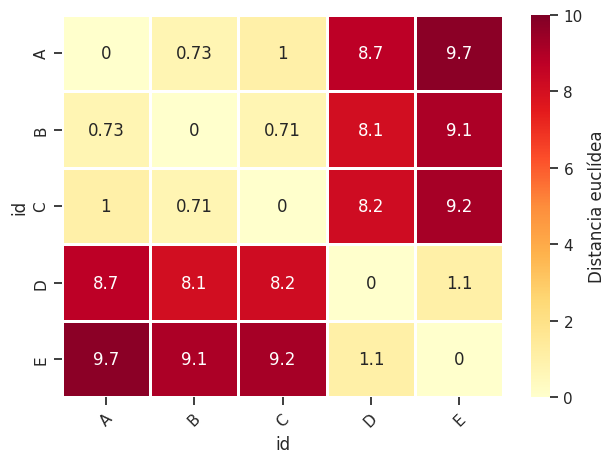

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style = 'ticks')

ax = sns.heatmap(dist_eucl, annot = True, cmap = 'YlOrRd', vmin = 0, vmax = 10,
                 linewidths = 0.9, annot_kws = {"fontsize": 12},
                 cbar_kws = dict(label = 'Distancia euclídea'))
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

El mapa de calor revela con claridad la estructura de los datos: las observaciones A, B y C son similares entre sí (celdas claras en la esquina superior izquierda), al igual que D y E (celdas claras en la esquina inferior derecha). En cambio, la distancia entre cualquier observación del primer grupo y cualquier observación del segundo es considerablemente mayor (celdas oscuras), lo que sugiere la existencia de dos grupos bien diferenciados en el espacio de las tres variables.

### Distancia Manhattan

También llamada **City-Block** o **Taxicab**, la distancia Manhattan entre dos observaciones se obtiene sumando las diferencias absolutas coordenada por coordenada:

$$d_{MHT}(
\mathbf{i}, \mathbf{j}) = |x_{1i} - x_{1j}| + |x_{2i} - x_{2j}| + \cdots + |x_{pi} - x_{pj}|$$

El nombre evoca la forma de desplazarse por las calles de una ciudad en cuadrícula —como Manhattan—, donde no es posible avanzar en diagonal sino solo en dirección horizontal o vertical. En ese contexto, la distancia entre dos puntos no es la línea recta que los une, sino la suma de los desplazamientos sobre cada eje. 

Retomando el ejemplo anterior, calculamos la matriz de distancias Manhattan usando `pdist` con `metric = 'cityblock'`:

In [12]:
# Matriz de distancias Manhattan
dist_manh = pd.DataFrame(
    squareform(pdist(df[['x1', 'x2', 'x3']], metric = 'cityblock')),
    index = df['id'],
    columns = df['id']
)

print(dist_manh.round(3))

id     A     B     C     D     E
id                              
A    0.0   1.2   1.4  15.0  16.8
B    1.2   0.0   1.2  13.8  15.6
C    1.4   1.2   0.0  14.0  15.8
D   15.0  13.8  14.0   0.0   1.8
E   16.8  15.6  15.8   1.8   0.0


**¿Cuándo preferir Manhattan sobre Euclídea?**

En espacios de alta dimensionalidad, la distancia Manhattan suele comportarse mejor que la euclídea. A medida que $p$ crece, las distancias euclídeas entre todos los pares de puntos tienden a concentrarse en un rango cada vez más estrecho, perdiendo capacidad discriminatoria. Este fenómeno se conoce como la *maldición de la dimensionalidad* (*curse of dimensionality*) y afecta de forma más severa a la distancia euclídea que a la Manhattan.

Más allá de este argumento general, la elección entre una y otra depende también de la naturaleza del problema. La distancia Manhattan es preferible cuando los datos se organizan de forma natural en cuadrícula y el movimiento diagonal no tiene sentido. También resulta más adecuada cuando los atributos contribuyen de forma aditiva e independiente, ya que acumula el desplazamiento total coordenada por coordenada sin amplificar las diferencias grandes mediante el cuadrado. La euclídea, en cambio, penaliza más fuertemente las diferencias grandes en una sola variable, lo que puede ser deseable o indeseable según el contexto.

### Distancia de Mahalanobis

La **distancia de Mahalanobis** fue propuesta por Prasanta Chandra Mahalanobis en 1936. A diferencia de las distancias euclídea y Manhattan, no trata a todas las direcciones del espacio por igual: incorpora la **estructura de variabilidad y correlación de los datos** para ajustar las distancias de acuerdo a la forma de la nube de puntos. Se utiliza con frecuencia en tareas de clasificación y detección de valores atípicos multivariados.

Para introducir la fórmula, es útil partir de la distancia euclídea escrita en su forma matricial. Dados dos vectores $\mathbf{r}_1$ y $\mathbf{r}_2$, cada uno representando una observación en $\mathbb{R}^p$ (es decir, un punto con $p$ coordenadas en el espacio de las variables), la distancia euclídea entre ellos puede expresarse como:

$$d_E(\mathbf{r}_1, \mathbf{r}_2) = \sqrt{(\mathbf{r}_1 - \mathbf{r}_2)^T \, \mathbf{I} \, (\mathbf{r}_1 - \mathbf{r}_2)}$$

donde $\mathbf{I}$ es la matriz identidad de orden $p \times p$. Multiplicar por $\mathbf{I}$ es equivalente a no transformar nada: cada dirección del espacio recibe el mismo peso, con independencia de cuánta variabilidad presenten los datos en esa dirección o de si las variables están correlacionadas entre sí.

La distancia de Mahalanobis parte de la misma expresión pero reemplaza $\mathbf{I}$ por la inversa de la matriz de covarianza $\boldsymbol{\Sigma}$:

$$d_M(\mathbf{r}_1, \mathbf{r}_2) = \sqrt{(\mathbf{r}_1 - \mathbf{r}_2)^T \, \boldsymbol{\Sigma}^{-1} \, (\mathbf{r}_1 - \mathbf{r}_2)}$$

$\boldsymbol{\Sigma}$ es la matriz de covarianza de los datos: una matriz $p \times p$ que resume, en su diagonal, la varianza de cada variable y, fuera de la diagonal, las covarianzas entre pares de variables. Al incorporar su inversa $\boldsymbol{\Sigma}^{-1}$, la distancia se ajusta automáticamente en dos sentidos: las direcciones en las que los datos presentan mayor variabilidad "pesan menos" (es natural encontrar puntos alejados en esa dirección, por lo que no se los penaliza tanto), mientras que las direcciones poco compatibles con la estructura de la nube "pesan más" (un desplazamiento en esa dirección resulta inusual y se refleja en una distancia mayor). En la práctica, cuando $\boldsymbol{\Sigma}$ no se conoce, se estima a partir de los datos usando la matriz de covarianza muestral $\mathbf{S}$.

#### Ejemplo ilustrativo

Para entender por qué la distancia euclídea puede resultar inadecuada cuando trabajamos con observaciones de variables cuantitativas que están correlacionadas, consideremos el siguiente escenario. Simulamos 50 observaciones de dos variables con una correlación lineal positiva muy fuerte ($\rho = 0.95$), y ubicamos tres puntos de interés: $P_1$ en el centro de la nube, $P_2$ dentro de la nube y alineado con su dirección principal de variación, y $P_3$ fuera de la nube, desplazado en una dirección poco compatible con su estructura.

In [13]:
import numpy as np

# Simulamos conjunto de datos
np.random.seed(3)
n, rho = 50, 0.95
x   = np.random.normal(size = n)
eps = np.random.normal(size = n)
y   = rho * x + np.sqrt(1 - rho**2) * eps
df_sim = pd.DataFrame({'x': x, 'y': y})

# DataFrame con puntos P1, P2 y P3
datos_puntos = pd.DataFrame({
    'punto': ['P1', 'P2', 'P3'],
    'X1':    [-0.15, 1.0,  -1.0],
    'X2':    [ 0.05, 1.05,  1.3149]
})

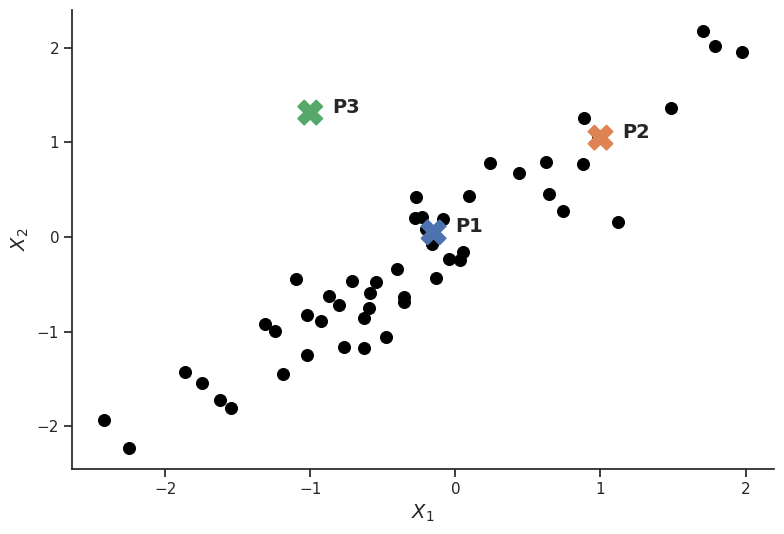

In [14]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(x='x', y='y', s = 75, data=df_sim, color='black', edgecolor='black')
sns.scatterplot(x='X1', y='X2', data=datos_puntos, hue='punto',
                marker='X', s = 300, legend=False, edgecolor=None)
for _, row in datos_puntos.iterrows():
    plt.text(row['X1'] + 0.15, row['X2'], row['punto'],
             fontsize=14, fontweight='bold')
plt.xlabel('$X_1$', fontsize = 14, fontweight='bold')
plt.ylabel('$X_2$', fontsize = 14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

Desde el punto de vista de la distancia euclídea, $P_2$ y $P_3$ se encuentran prácticamente a la misma distancia de $P_1$:

In [15]:
dist_eucl = pd.DataFrame(
    squareform(pdist(datos_puntos[['X1', 'X2']], metric = 'euclidean')),
    index = datos_puntos['punto'],
    columns = datos_puntos['punto']
)
dist_eucl.index.name = dist_eucl.columns.name = None
print(dist_eucl.round(3))

       P1     P2     P3
P1  0.000  1.524  1.524
P2  1.524  0.000  2.017
P3  1.524  2.017  0.000


Sin embargo, observando la forma de la nube, esta conclusión resulta contraintuitiva: $P_2$ sigue la dirección principal de variación de los datos y se encuentra perfectamente dentro de su estructura, mientras que $P_3$ se aparta de ella en una dirección que los datos prácticamente nunca toman. Desde el punto de vista estadístico, $P_3$ es mucho más atípico (está "mucho más lejos" de $P_1$ en el contexto del conjunto de datos de estas variables) que $P_2$, aunque la distancia euclídea no lo refleje.

La distancia de Mahalanobis corrige exactamente esto. Calculamos $\boldsymbol{S}^{-1}$ a partir de los datos simulados —que ofician de distribución de referencia— y la usamos para calcular las distancias entre los tres puntos:

In [16]:
from scipy.spatial.distance import mahalanobis

# Calculamos la inversa de la matriz de covarianza (estimada a partir de los datos simulados)
S_inv = np.linalg.inv(np.cov(df_sim[['x', 'y']].T))

# Extraemos las coordenadas y los nombres de los tres puntos
puntos = datos_puntos[['X1', 'X2']].values
ids    = datos_puntos['punto'].values

# Inicializamos una matriz de ceros de 3x3 para ir llenando
dist_mahal = np.zeros((len(puntos), len(puntos)))

# El bucle es necesario porque mahalanobis() requiere que le pasemos
# S_inv explícitamente. pdist() no admite ese parámetro externo,
# por lo que no podemos usarlo aquí como con la euclídea o Manhattan.
for i in range(len(puntos)):
    for j in range(len(puntos)):
        dist_mahal[i, j] = mahalanobis(puntos[i], puntos[j], S_inv)

dist_mahal_df = pd.DataFrame(dist_mahal, index = ids, columns = ids)
print(dist_mahal_df.round(3))

       P1     P2     P3
P1  0.000  1.178  6.083
P2  1.178  0.000  6.625
P3  6.083  6.625  0.000


Ahora $d_M(P_1, P_2)$ < $d_M(P_1, P_3)$: la distancia de Mahalanobis reconoce que $P_2$ es más compatible con la estructura de los datos que $P_3$, capturando lo que la distancia euclídea no podía.

#### Ejemplo con el dataset Iris

Para ver una aplicación más concreta, utilizaremos el dataset Iris. Consideraremos únicamente dos variables —`sepal_length` y `petal_length`— para facilitar la visualización.

In [17]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


```{figure} imagenes/iris.svg
---
width: 70%
align: center
---
```

El objetivo es el siguiente: dada una nueva planta con `sepal_length = 7` y `petal_length = 5`, ¿a qué especie pertenece?

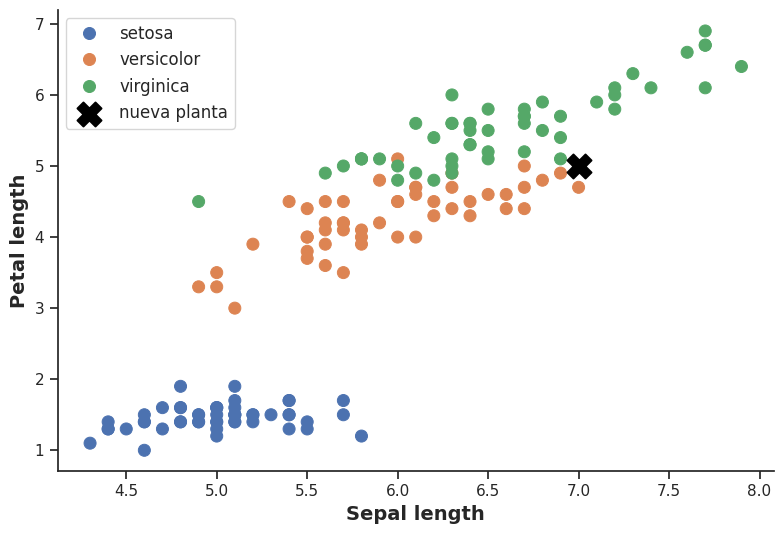

In [18]:
iris = sns.load_dataset('iris')
nuevo_punto = np.array([7, 5])
punto = pd.DataFrame({'sepal_length': [7], 'petal_length': [5]})

plt.figure(figsize=(8, 5.5))
sns.scatterplot(x='sepal_length', y='petal_length', s=75,
                data=iris, hue='species', edgecolor=None)
sns.scatterplot(x='sepal_length', y='petal_length', data=punto,
                color='black', marker='X', s=300,
                label='nueva planta', edgecolor=None)
plt.xlabel('Sepal length', fontsize=14, fontweight='bold')
plt.ylabel('Petal length', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
sns.despine()
plt.tight_layout()
plt.show()

Intuitivamente, aunque la nueva planta pueda estar próxima a varios puntos de *virginica* bajo la lógica de una distancia euclídea, visualmente parece encontrarse dentro de la región que ocupa *versicolor*: está alineada con la forma y dispersión de ese grupo. Para responder la pregunta de forma rigurosa, calculamos la distancia de Mahalanobis de la nueva planta al **centroide** de cada especie, usando la matriz de covarianza muestral de cada especie como referencia:

In [19]:
vars_sel = ['sepal_length', 'petal_length']
dist_centroid = []

for especie, grupo in iris.groupby('species'):
    centroide  = grupo[vars_sel].mean().values
    cov_matrix = np.cov(grupo[vars_sel].T)
    inv_cov    = np.linalg.inv(cov_matrix)
    d          = mahalanobis(nuevo_punto, centroide, inv_cov)
    dist_centroid.append({'species': especie, 'dist_mahal': d})

dist_centroid_df = pd.DataFrame(dist_centroid)
print(dist_centroid_df.round(3))

      species  dist_mahal
0      setosa      20.374
1  versicolor       2.062
2   virginica       3.168


La nueva planta se clasificaría como ***versicolor***: es la especie cuyo centroide presenta la menor distancia de Mahalanobis al nuevo punto, confirmando la intuición visual.

#### Ventajas de la distancia de Mahalanobis

**Considera la correlación entre variables.** Al incorporar la matriz de covarianza, ajusta las distancias según la forma y orientación de la nube de datos. Dos variables fuertemente correlacionadas no aportan información independiente, y la distancia de Mahalanobis lo tiene en cuenta: no penaliza desplazamientos en direcciones que los datos recorren habitualmente.

**Es invariante a la escala.** No requiere estandarizar previamente las variables. La multiplicación por $\boldsymbol{S}^{-1}$ pondera automáticamente cada variable según su variabilidad, de modo que variables con rangos muy distintos contribuyen de forma equilibrada al cálculo.

**Permite detectar valores atípicos multivariados.** Una observación puede ser perfectamente normal en cada variable por separado y, sin embargo, resultar atípica por la combinación inusual de sus valores. La distancia de Mahalanobis al centroide del grupo captura exactamente este tipo de anomalías, que la distancia euclídea y los métodos univariados no detectarían.

### Similaridad de coseno

#### Representación vectorial de documentos: Bag of Words
Para poder comparar documentos de texto de forma cuantitativa, primero necesitamos representarlos numéricamente. El modelo **Bag of Words** (BoW) es la representación más simple: cada documento se convierte en un vector donde cada dimensión corresponde a una palabra del vocabulario y su valor indica cuántas veces aparece esa palabra en el documento (frecuencia de término o *term frequency*).

**Ejemplo:**

| | "ciencia" | "datos" | "modelo" | "error" |
|---|---|---|---|---|
| doc1 | 2 | 3 | 1 | 0 |
| doc2 | 1 | 2 | 0 | 4 |
| doc3 | 2 | 3 | 1 | 0 |

En el documento 1 (`doc1`), por ejemplo, la palabra "ciencia" aparece 2 veces, "datos" 3 veces y "modelo" 1 vez. En la práctica, el vocabulario puede tener miles o decenas de miles de palabras, por lo que estos vectores suelen ser muy largos y con muchos ceros (vectores *sparse* o dispersos).

### ¿Por qué no usar la distancia euclídea para comparar documentos?

Dado que representamos cada documento mediante un vector, podría parecer natural calcular la similaridad entre documentos a partir de la distancia euclídea entre ellos, y concluir que dos documentos son temáticamente similares si dicha distancia es pequeña. Sin embargo, esto presenta un problema importante que ilustramos a continuación.

Consideremos tres documentos representados con BoW:

| | "modelo" | "embeddings" |
|---|---|---|
| doc1 | 10 | 2 |
| doc2 | 150 | 7 |
| doc3 | 2 | 18 |

`doc1` y `doc2` hablan principalmente de "modelo" y son temáticamente similares, pero `doc2` es mucho más largo. Aunque las proporciones en que aparecen los términos son similares, la distancia euclídea entre ellos será grande debido a la diferencia de magnitud entre sus vectores. El documento `doc3`, en cambio, habla principalmente de "embeddings" y es temáticamente distinto, pero tiene una magnitud similar a `doc1`, por lo que la distancia euclídea entre ambos resultará pequeña, a pesar de que apuntan en direcciones muy distintas.

La raíz del problema es que la distancia euclídea es sensible a la **longitud del documento**: documentos más largos tienen vectores de mayor magnitud, lo que distorsiona la comparación temática.

<br>

La **similaridad de coseno** resuelve este problema: en lugar de medir la distancia entre los extremos de los vectores, mide **el ángulo entre ellos**. Dos vectores que apuntan en la misma dirección —independientemente de su magnitud— tienen ángulo cero y similaridad coseno máxima.

```{figure} imagenes/cosine.png
---
width: 50%
align: center
---
Dos vectores $\mathbf{i}$ y $\mathbf{j}$ en un espacio bidimensional forman un ángulo $\theta$ entre ellos. La similaridad de coseno es el coseno de dicho ángulo.
```

Para dos vectores $\mathbf{i}$ y $\mathbf{j}$:

$$sim_{COS}(\mathbf{i}, \mathbf{j}) = \frac{\mathbf{i} \cdot \mathbf{j}}{\lVert \mathbf{i} \rVert \, \lVert \mathbf{j} \rVert}$$

donde $\lVert \mathbf{w} \rVert = \sqrt{w_1^2 + w_2^2 + \cdots + w_p^2}$ es la **norma euclídea** del vector $\mathbf{w}$. El cociente divide el producto punto por el producto de las normas, lo que equivale a **normalizar ambos vectores** antes de compararlos. Por eso el resultado no depende de la magnitud (longitud) de los vectores.

**Interpretación:**

- Si $sim_{COS} = 1$: los vectores apuntan en exactamente la misma dirección. Los documentos son temáticamente muy similares.

- Si $sim_{COS} = 0$: los vectores son ortogonales. En el contexto de frecuencias de términos, esto implica que los documentos no comparten ningún término en común.

```{admonition} ¿Qué valores puede tomar la similaridad de coseno?
:class: tip

En el contexto de vectores de frecuencias de términos, todos los valores son no negativos, por lo que $sim_{COS} \in [0, 1]$. En otros contextos donde los vectores pueden tener valores negativos (por ejemplo, en embeddings de palabras o representaciones TF-IDF centradas), la similaridad puede tomar valores en $[-1, 1]$.
```

#### Implementación en Python

La función `cosine()` de `scipy.spatial.distance` calcula la **distancia coseno**, que se define como $1 - sim_{COS}$. Para obtener la similaridad debemos restarla a 1.

**Ejemplo 1: comparación de los tres documentos**

In [20]:
from scipy.spatial.distance import cosine

doc1 = [10, 2]
doc2 = [150, 7]
doc3 = [2, 18]

print("Similaridades de coseno:")
print("sim(doc1, doc2):", round(1 - cosine(doc1, doc2), 3))
print("sim(doc1, doc3):", round(1 - cosine(doc1, doc3), 3))
print("sim(doc2, doc3):", round(1 - cosine(doc2, doc3), 3))

Similaridades de coseno:
sim(doc1, doc2): 0.989
sim(doc1, doc3): 0.303
sim(doc2, doc3): 0.157


La similaridad entre `doc1` y `doc2` resulta alta, reflejando que ambos documentos tratan principalmente la misma temática en proporciones similares, a pesar de la gran diferencia en su longitud. La similaridad entre `doc1` y `doc3` es baja, lo que coincide con la interpretación temática: hablan de cosas distintas.

Comparemos este resultado con la distancia euclídea entre los mismos documentos:

In [21]:
documentos = pd.DataFrame({
    'id': ['doc1', 'doc2', 'doc3'],
    'modelo': [10, 150, 2],
    'embed': [2, 7, 18]
})

dist_eucl_docs = pd.DataFrame(
    squareform(pdist(documentos[['modelo', 'embed']], metric = 'euclidean')),
    index = documentos['id'],
    columns = documentos['id']
)

print("Distancias euclídeas:")
print(dist_eucl_docs.round(3))

Distancias euclídeas:
id       doc1     doc2     doc3
id                             
doc1    0.000  140.089   17.889
doc2  140.089    0.000  148.408
doc3   17.889  148.408    0.000


La distancia euclídea entre `doc1` y `doc2` es enorme (por diferencia de longitud), y entre `doc1` y `doc3` es pequeña (ambos tienen vectores de magnitud similar). Este resultado es contrario a la interpretación temática: la similiaridad de coseno es mucho más adecuada para comparar documentos.

**Ejemplo 2**

Se cuenta con 5 documentos con los siguientes vectores de frecuencias de términos:

```{figure} imagenes/tabla-cosine.png
---
width: 70%
align: center
---
Ejemplo extraído de *Data Mining: Concepts and Techniques* (Han, Kamber & Pei, 2012).
```

Supongamos que $\mathbf{d_1}$ y $\mathbf{d_2}$ son vectores de frecuencia de términos para los dos primeros documentos sobre un vocabulario de 10 palabras:

```python
d1 = [5, 0, 3, 0, 2, 0, 0, 2, 0, 0]
d2 = [3, 0, 2, 0, 1, 1, 0, 1, 0, 1]

cos_sim = 1 - cosine(d1, d2)
print("Similaridad coseno entre i y j:", round(cos_sim, 3))
```

El valor obtenido es cercano a 1, lo que indica que `d1` y `d2` son muy similares en composición temática. Ambos documentos comparten términos activos en las mismas posiciones principales —posiciones 0, 2, 4 y 7— y las diferencias en sus frecuencias son pequeñas, lo que explica la alta similaridad.

## Manos a la obra

Queda como ejercicio construir la matriz de similaridades de coseno entre los pares de documentos del ejemplo anterior.